<a href="https://colab.research.google.com/github/iking919/Projects-in-AI-and-ML/blob/main/ProjectsInMLandAI_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projects in ML & AI HW3 - Izaak King

## Dataset Selection:


For this project, we use the NFL play-by-play dataset covering the 2009–2016 seasons, which contains over 350,000 plays and a wide variety of features describing game context, play type, player actions, and scoring outcomes. The goal of this project is to build a supervised learning model that predicts whether an offensive play will be successful. Success is defined as the play resulting in either a first down or a touchdown. By predicting play success, we can explore the factors that influence offensive efficiency and evaluate the performance of neural network models on a large, real-world sports dataset.

The dataset was found on kaggle: https://www.kaggle.com/datasets/maxhorowitz/nflplaybyplay2009to2016

### **Note:**
Throughout this homework, the NFL play‑by‑play dataset has proven to be inherently difficult to model because individual plays are driven by many high-variance, context dependent factors. While variables such as down, distance, and field position are included in the dataset, many of the most influential elements, like player decision‑making, defensive schemes, in‑game adjustments, and coaching strategy, are not directly observable. This missing contextual information introduces noise and unpredictability, which limits the performance of supervised learning models. As a result, even well‑designed neural networks tend to achieve modest precision, recall, and F1 scores, reflecting the complexity and randomness of play‑level outcomes


 First loading the dataset

In [ ]:
import kagglehub
import pandas as pd
import os
import numpy as np

# Download dataset
path = kagglehub.dataset_download("maxhorowitz/nflplaybyplay2009to2016")

# Find CSV file
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
csv_path = os.path.join(path, csv_files[0])

# Load into DataFrame
df = pd.read_csv(csv_path, low_memory=False)

print(df.shape)


100%|██████████| 274M/274M [00:10<00:00, 27.1MB/s]

Extracting files...


(362447, 102)


Now we begin preparing our dataset, by creating a "Success" label, which is used to indicate if the play was successful (First Down or Touchdown). We drop plasys that aren't Run or Pass plays, and we drop plays that result in a penalty or qb kneel, which are outliers that will negatively influence our model.

Next we drop columns from our dataset, for various reasons. Some are leakage, like "Yards.Gained" or "PassOutcome" which will indicate whether a play was successful. Some are probability based, or derived from other models, and therefore shouldn't be included. Some are used to identify players, like "Passer_ID" or "Rusher". Some are outcome descriptors like "PassLength" and "AirYards" which would also contribute to leakage. Lastly, some are administrative, like "GameID" or "Date".

Thus, we arrive at our final data frame consisting of 18 total features, including information like time left in the game ("Qtr", "TimeSecs", etc.), the context of the game ("ScoreDiff", "OffenseIsAway", "HomeTimeout_Remeaining_Pre", etc.), and the context of the down ("down", "ydstogo", etc.).

In [ ]:
# Creating "Success" label (1 if 1st down or touchdown, 0 if otherwise)
df["Success"] = ((df["FirstDown"] == 1) | (df["Touchdown"] == 1)).astype(int)

# Keep only run or pass plays
df = df[df["PlayType"].isin(["Run", "Pass"])]
df = df[df["PlayAttempted"] == 1]

# Exclude penalties, QB kneels
df = df[df["Accepted.Penalty"] != 1]
df = df[~df["desc"].str.contains("kneel", case=False, na=False)]

# Encode which team is on offense
# OffensiveTeam = 1 if away team on offense, 0 if home team on offense
df["OffenseIsAway"] = (df["DefensiveTeam"] == df["HomeTeam"]).astype(int)

# Select only the features we need
tfeatures = [
    "qtr", "TimeSecs", "TimeUnder", "PlayTimeDiff",
    "down", "ydstogo", "yrdline100", "GoalToGo",
    "ScoreDiff", "AbsScoreDiff", "PosTeamScore", "DefTeamScore",
    "posteam_timeouts_pre", "HomeTimeouts_Remaining_Pre", "AwayTimeouts_Remaining_Pre",
    "PassAttempt",
    "OffenseIsAway"  # newly created feature
]

# Keep only these features + the label
df_model = df[tfeatures + ["Success"]]

# Drop DefensiveTeam column (we no longer need it)
if "DefensiveTeam" in df_model.columns:
    df_model = df_model.drop(columns=["DefensiveTeam"])

# Drop any rows with NA in these features
df_model = df_model.dropna()

# Examine the size and shape of the data frame
print(df_model.shape)
print(df_model["Success"].value_counts(normalize=True))
print(df_model.columns)


(244962, 18)
Success
0    0.699317
1    0.300683
Name: proportion, dtype: float64
Index(['qtr', 'TimeSecs', 'TimeUnder', 'PlayTimeDiff', 'down', 'ydstogo',
       'yrdline100', 'GoalToGo', 'ScoreDiff', 'AbsScoreDiff', 'PosTeamScore',
       'DefTeamScore', 'posteam_timeouts_pre', 'HomeTimeouts_Remaining_Pre',
       'AwayTimeouts_Remaining_Pre', 'PassAttempt', 'OffenseIsAway',
       'Success'],
      dtype='object')


Thus we are left with a dataframe with 275,000+ rows and 18 columns.

## Part 1: Neural Network Implementation

We will now implement a neural network from scratch, that has the following

*  Initialization method.
*  Forward propagation method that performs forward propagation calculations.
*  Backward propagation method that implements the backpropagation algorithm discussed in class.
*  Train method that includes the code for gradient descent.
*  Cost method that calculates the loss function.
*  Predict method that calculates the predictions for the test set.

The selected dataset contains over 275,000 observations, which makes full-batch gradient descent computationally inefficient when implementing a neural network from scratch using NumPy. To address this, a subset of 35,000 observations was randomly sampled from the full dataset while preserving the class distribution through stratified sampling. This allowed the model to be trained efficiently while still retaining sufficient data complexity.

In addition, mini-batch gradient descent was implemented instead of full-batch gradient descent. At each training epoch, the data was shuffled and divided into mini-batches of fixed size, and parameter updates were performed after each mini-batch. This approach significantly reduced runtime and memory usage compared to full-batch updates, while providing more stable convergence than purely stochastic gradient descent.

Mini-batch gradient descent represents a practical compromise between computational efficiency and training stability, making it well-suited for large datasets and from-scratch neural network implementations.


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Success"]).values
y = df_model["Success"].values.reshape(-1, 1)  # column vector

# Subsample 35,000
X, _, y, _ = train_test_split(X, y, train_size=35000, stratify=y, random_state=42)

# First split off 2% (1% val + 1% test)
X_train, X_small, y_train, y_small = train_test_split(
    X, y, test_size=0.02, stratify=y, random_state=42
)

# Split the 2% into val and test (1% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_small, y_small, test_size=0.5, stratify=y_small, random_state=42
)

print("Shapes after 98-1-1 split:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes after 98-1-1 split:
X_train: (34300, 17) y_train: (34300, 1)
X_val: (350, 17) y_val: (350, 1)
X_test: (350, 17) y_test: (350, 1)


We use a preprocessing pipeline to scale all the numeric features of our training data. Then, we apply this to our validation and test data.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# User-defined indices of numerical features
numeric_idx = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

# Create a preprocessor to scale numerical features using the specified indices
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_idx)
    ],
    remainder='passthrough' # Keep other columns as they are
)

# Create a pipeline with the preprocessor
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit the pipeline on X_train and transform
X_train_scaled = pipeline.fit_transform(X_train)

# Transform X_val and X_test using the fitted pipeline
X_val_scaled = pipeline.transform(X_val)
X_test_scaled = pipeline.transform(X_test)

Implementation of Neural Network Class

In [ ]:
class NeuralNetwork:
    """
    Two-layer Neural Network for binary classification
    Architecture: Input -> Hidden (ReLU) -> Output (Sigmoid)
    """

    def __init__(self, n_x, n_h, learning_rate=0.01, seed=42):
        """
        Initialization method
        n_x: number of input features
        n_h: number of hidden units
        """
        np.random.seed(seed)

        # Weight initialization (small random values)
        self.W1 = np.random.randn(n_h, n_x) * 0.01
        self.b1 = np.zeros((n_h, 1))

        self.W2 = np.random.randn(1, n_h) * 0.01
        self.b2 = np.zeros((1, 1))

        self.learning_rate = learning_rate

    # Activation functions
    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    # Forward propagation
    def forward(self, X):
        """
        Forward propagation
        X shape: (n_features, m)
        """
        self.Z1 = self.W1 @ X + self.b1
        self.A1 = self.relu(self.Z1)

        self.Z2 = self.W2 @ self.A1 + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2

    # Cost function
    def cost(self, Y, A2):
        """
        Binary cross-entropy loss
        """
        m = Y.shape[1]
        epsilon = 1e-8  # numerical stability

        cost = - (1 / m) * np.sum(
            Y * np.log(A2 + epsilon) + (1 - Y) * np.log(1 - A2 + epsilon)
        )

        return cost

    # Backward propagation
    def backward(self, X, Y):
        """
        Backpropagation
        """
        m = X.shape[1]

        # Output layer gradients
        dZ2 = self.A2 - Y
        dW2 = (1 / m) * dZ2 @ self.A1.T
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

        # Hidden layer gradients
        dA1 = self.W2.T @ dZ2
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        dW1 = (1 / m) * dZ1 @ X.T
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

        # Gradient descent update
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    # Training loop
    def train(self, X, Y, epochs=1000, batch_size=256):
        """
        Mini-batch gradient descent
        """
        m = X.shape[1]

        for epoch in range(epochs):
            permutation = np.random.permutation(m)
            X_shuffled = X[:, permutation]
            Y_shuffled = Y[:, permutation]

            for i in range(0, m, batch_size):
                X_batch = X_shuffled[:, i:i+batch_size]
                Y_batch = Y_shuffled[:, i:i+batch_size]

                A2 = self.forward(X_batch)
                self.backward(X_batch, Y_batch)

            if epoch % 100 == 0:
                cost = self.cost(Y, self.forward(X))

    # Prediction
    def predict(self, X, threshold=0.5):
        """
        Predict class labels
        """
        probs = self.forward(X)
        return (probs >= threshold).astype(int)


Now we create our Neural Network models using our training data. We use a list of parameters for learning rate (0.001, 0.01, 0.1) and hidden_units_list (8, 16, 32, 64), comparing which parameters perform best for our validation data.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Transpose features
X_train_nn = X_train_scaled.T
X_val_nn   = X_val_scaled.T
X_test_nn  = X_test_scaled.T

# Transpose labels
y_train_nn = y_train.T
y_val_nn   = y_val.T
y_test_nn  = y_test.T

n_features = X_train_nn.shape[0]

# Define parameter list
hidden_units_list = [8, 16, 32, 64]
learning_rates = [0.001, 0.01, 0.1]

results = []

for n_h in hidden_units_list:
    for lr in learning_rates:
        print(f"\nTraining model: n_h={n_h}, learning_rate={lr}")

        nn = NeuralNetwork(
            n_x=n_features,
            n_h=n_h,
            learning_rate=lr
        )

        nn.train(
            X_train_nn,
            y_train_nn,
            epochs=500,          # fewer epochs for tuning
            batch_size=256
        )

        # Validation predictions
        y_val_pred = nn.predict(X_val_nn)

        # Flatten for sklearn metrics
        y_true = y_val_nn.flatten()
        y_pred = y_val_pred.flatten()

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        results.append((n_h, lr, acc, prec, rec, f1))

        print(
            f"Accuracy: {acc:.4f} | "
            f"Precision: {prec:.4f} | "
            f"Recall: {rec:.4f} | "
            f"F1: {f1:.4f}"
        )

# Get bes parameters pased on F1 Score
best_model = max(results, key=lambda x: x[-1])

n_h_best, lr_best, acc_best, prec_best, rec_best, f1_best = best_model

print("\nBest model based on validation F1 score:")
print(f"Hidden units (n_h): {n_h_best}")
print(f"Learning rate: {lr_best}")
print(f"Accuracy:  {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall:    {rec_best:.4f}")
print(f"F1 Score:  {f1_best:.4f}")



Training model: n_h=8, learning_rate=0.001
Accuracy: 0.7371 | Precision: 0.6275 | Recall: 0.3048 | F1: 0.4103

Training model: n_h=8, learning_rate=0.01
Accuracy: 0.7400 | Precision: 0.6400 | Recall: 0.3048 | F1: 0.4129

Training model: n_h=8, learning_rate=0.1
Accuracy: 0.7314 | Precision: 0.6279 | Recall: 0.2571 | F1: 0.3649

Training model: n_h=16, learning_rate=0.001
Accuracy: 0.7486 | Precision: 0.6441 | Recall: 0.3619 | F1: 0.4634

Training model: n_h=16, learning_rate=0.01
Accuracy: 0.7371 | Precision: 0.6383 | Recall: 0.2857 | F1: 0.3947

Training model: n_h=16, learning_rate=0.1
Accuracy: 0.7400 | Precision: 0.6346 | Recall: 0.3143 | F1: 0.4204

Training model: n_h=32, learning_rate=0.001
Accuracy: 0.7486 | Precision: 0.6441 | Recall: 0.3619 | F1: 0.4634

Training model: n_h=32, learning_rate=0.01
Accuracy: 0.7314 | Precision: 0.6279 | Recall: 0.2571 | F1: 0.3649

Training model: n_h=32, learning_rate=0.1
Accuracy: 0.7257 | Precision: 0.5882 | Recall: 0.2857 | F1: 0.3846

Tra

Now, using our best performing model (Hidden units = 16, Learning rate 0.001) on our test data.

In [ ]:
n_features = X_train_nn.shape[0]
best_nn_model = NeuralNetwork(
    n_x=n_features,
    n_h=n_h_best,  # Use the best n_h found (16)
    learning_rate=lr_best # Use the best learning_rate found (0.001)
)

print(f"Training the best model with n_h={n_h_best}, learning_rate={lr_best}")
best_nn_model.train(
    X_train_nn,
    y_train_nn,
    epochs=1000,
    batch_size=256
)

# Make predictions on the test set using the best model
y_test_pred = best_nn_model.predict(X_test_nn)

# Flatten y_test for sklearn metrics
y_test_true = y_test_nn.flatten()
y_test_pred_flat = y_test_pred.flatten()

# Calculate metrics
accuracy = accuracy_score(y_test_true, y_test_pred_flat)
precision = precision_score(y_test_true, y_test_pred_flat, zero_division=0)
recall = recall_score(y_test_true, y_test_pred_flat)
f1 = f1_score(y_test_true, y_test_pred_flat)

print("Performance on Test Data:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Training the best model with n_h=16, learning_rate=0.001
Performance on Test Data:
Accuracy:  0.7371
Precision: 0.6182
Recall:    0.3238
F1 Score:  0.4250


### Conclusion and Discussion

The best-performing model achieved a test accuracy of approximately 73% and an F1 score of 0.41. While this represents a meaningful improvement over a naive baseline that always predicts an unsuccessful play, overall performance remains moderate. This limitation can be largely attributable to the nature of the NFL play-by-play data itself rather than flaws in the neural network implementation.

For context of the dataset, predicting play success using only pre-snap contextual features is inherently challenging. Many critical factors that influence the outcome of a play, such as defensive alignment, coverage schemes, player matchups, blocking execution, and quarterback decision-making, are not captured in the available dataset. As a result, a significant portion of the outcome variance remains unobservable to the model, imposing a natural upper bound on achievable performance.

Additionally, the dataset exhibits moderate class imbalance, with successful plays occurring less frequently than unsuccessful ones. This imbalance contributes to lower recall and F1 scores, as the model tends to favor predicting the majority class. Future work could address this by incorporating class-weighted loss functions or alternative decision thresholds to better balance precision and recall.

Further performance improvements may also be obtained by increasing model capacity. The from-scratch implementation was intentionally limited to a single hidden layer to maintain computational efficiency and conceptual clarity. In Part 2 of this project, deeper architectures will be explored using a modern deep learning framework, allowing for additional hidden layers.

Overall, the results demonstrate that while simple neural networks can capture meaningful patterns in NFL play success, more expressive models and richer feature representations are necessary to overcome the inherent uncertainty present in real-world sports data.

## Part 2: 2-layer Neural Network

### Task 1: Research on Framework for a 2-Layer Neural Network

For this project, I chose to use PyTorch as the deep learning framework to implement a 2-layer neural network.

To learn PyTorch and prepare for this implementation, I consulted several resources. The PyTorch Beginner Basics tutorials helped me understand tensor operations, automatic differentiation, and the computation graph ([PyTorch Tensor Tutorial](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html) and [PyTorch Autograd Tutorial](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)). These resources were necessary to track all computations in the network and implement gradient-based updates efficiently. Additionally, the Build a Model Tutorial provided guidance on defining a neural network using torch.nn.Module and setting up layers, activations, and output functions ([Build Model Tutorial](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)).

Handling data and batching is also critical for neural network training, especially with a dataset containing over 350,000 NFL plays. The DataLoader and Dataset tutorials explained how to convert tabular data into PyTorch tensors and efficiently load it in batches for training ([Data Tutorial](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html)). Finally, for optimization and evaluation, I used resources on optimizers and metrics, including the Adam, Adagrad and RMSProp optimizers, as well as precision, recall, and F1 metrics for evaluating the model ([PyTorch Optimizers](https://docs.pytorch.org/docs/stable/optim.html) and [Scikit-learn Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)).

These resources collectively provided all the tools needed to implement a 2-layer neural network. The tensor operations and autograd features allowed me to perform forward and backward propagation, the model-building tutorial guided the network structure, and the data handling and evaluation resources ensured proper training and assessment of performance. Together, they form a complete foundation for implementing and experimenting with neural networks on complex, real-world datasets like the NFL play-by-play data.

## Task 2: Design and Implementation

### 1. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure, distributions, and relationships within the dataset prior to our modeling using the PyTorch framework. This includes examining class balance, feature distributions, correlations between variables, and relationships between features and the target variable. Since neural networks are sensitive to feature scaling and data quality, EDA also helps motivate normalization and model design choices.

Dataset Overview

In [ ]:
# Basic info
print("Shape of dataset:", df_model.shape)
df_model.head()

Shape of dataset: (244962, 18)


,qtr,TimeSecs,TimeUnder,PlayTimeDiff,down,ydstogo,yrdline100,GoalToGo,ScoreDiff,AbsScoreDiff,PosTeamScore,DefTeamScore,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,PassAttempt,OffenseIsAway,Success
1,1,3593.0,15,7.0,1.0,10,58.0,0.0,0.0,0.0,0.0,0.0,3,3,3,1,0,0
2,1,3556.0,15,37.0,2.0,5,53.0,0.0,0.0,0.0,0.0,0.0,3,3,3,0,0,0
3,1,3515.0,14,41.0,3.0,8,56.0,0.0,0.0,0.0,0.0,0.0,3,3,3,1,0,0
5,1,3496.0,14,11.0,1.0,10,98.0,0.0,0.0,0.0,0.0,0.0,3,3,3,0,1,0
6,1,3460.0,13,36.0,2.0,10,98.0,0.0,0.0,0.0,0.0,0.0,3,3,3,1,1,0


In [ ]:
# Data types and non-null counts
df_model.info()

# Summary statistics
df_model.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 244962 entries, 1 to 362442
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   qtr                         244962 non-null  int64  
 1   TimeSecs                    244962 non-null  float64
 2   TimeUnder                   244962 non-null  int64  
 3   PlayTimeDiff                244962 non-null  float64
 4   down                        244962 non-null  float64
 5   ydstogo                     244962 non-null  int64  
 6   yrdline100                  244962 non-null  float64
 7   GoalToGo                    244962 non-null  float64
 8   ScoreDiff                   244962 non-null  float64
 9   AbsScoreDiff                244962 non-null  float64
 10  PosTeamScore                244962 non-null  float64
 11  DefTeamScore                244962 non-null  float64
 12  posteam_timeouts_pre        244962 non-null  int64  
 13  HomeTimeouts_Remain

,qtr,TimeSecs,TimeUnder,PlayTimeDiff,down,ydstogo,yrdline100,GoalToGo,ScoreDiff,AbsScoreDiff,PosTeamScore,DefTeamScore,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,PassAttempt,OffenseIsAway,Success
count,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000,244962.000000
mean,2.551906,1741.678738,7.781672,23.226419,1.784999,8.609629,52.537349,0.058038,-1.354724,7.782905,9.998710,11.353434,2.564194,2.592263,2.567051,0.568974,0.497673,0.300683
std,1.132724,1056.914442,4.484354,17.829817,0.814149,3.923975,24.722210,0.233815,10.725182,7.502730,9.319658,10.011860,0.741489,0.707097,0.728291,0.495221,0.499996,0.458556
min,1.000000,-899.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-59.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-1.000000,0.000000,0.000000,0.000000
25%,2.000000,831.000000,4.000000,6.000000,1.000000,6.000000,34.000000,0.000000,-7.000000,3.000000,0.000000,3.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,3.000000,1800.000000,8.000000,27.000000,2.000000,10.000000,56.000000,0.000000,0.000000,7.000000,7.000000,10.000000,3.000000,3.000000,3.000000,1.000000,0.000000,0.000000
75%,4.000000,2646.000000,12.000000,38.000000,2.000000,10.000000,73.000000,0.000000,4.000000,11.000000,16.000000,17.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000
max,5.000000,3600.000000,15.000000,940.000000,4.000000,50.000000,99.000000,1.000000,59.000000,59.000000,61.000000,61.000000,3.000000,3.000000,3.000000,1.000000,1.000000,1.000000


Target Variable Distribution

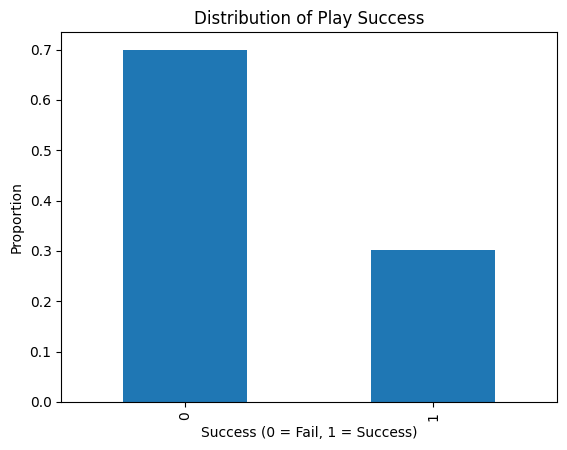

,proportion
Success,
0,0.699317
1,0.300683


In [ ]:
import matplotlib.pyplot as plt

success_counts = df_model["Success"].value_counts(normalize=True)

plt.figure()
success_counts.plot(kind="bar")
plt.title("Distribution of Play Success")
plt.ylabel("Proportion")
plt.xlabel("Success (0 = Fail, 1 = Success)")
plt.show()

success_counts

Feature Distribution

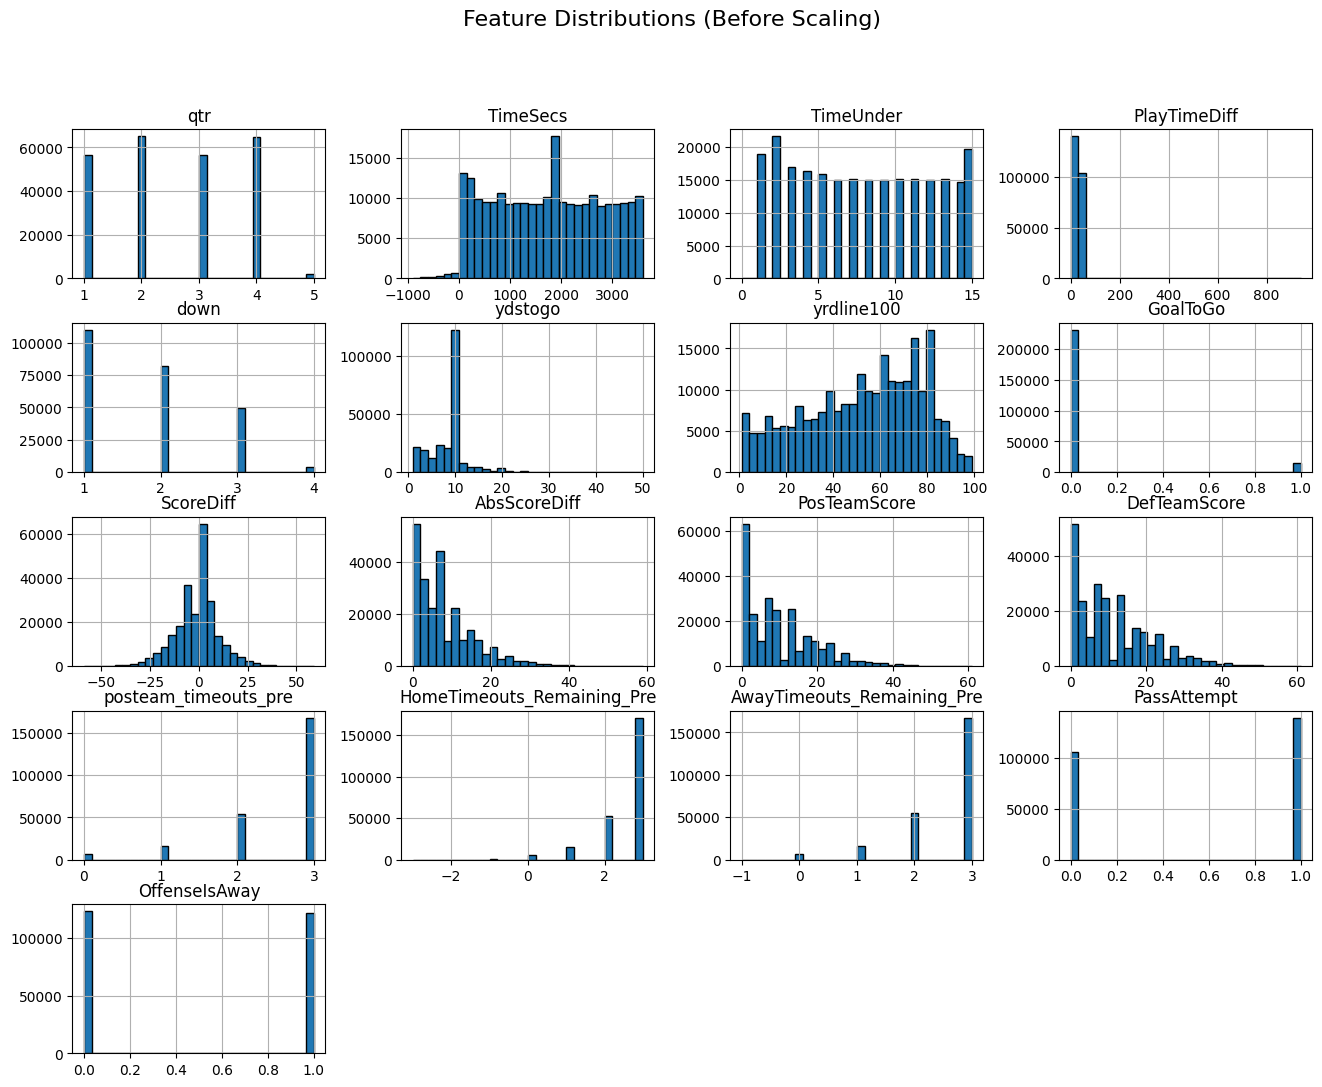

In [ ]:
numeric_features = df_model.drop(columns=["Success"]).columns

df_model[numeric_features].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor="black"
)
plt.suptitle("Feature Distributions (Before Scaling)", fontsize=16)
plt.show()

Boxplots for key continuous features (ydstogo, yrdline100, ScoreDiff, TimeSecs)

<Figure size 640x480 with 0 Axes>

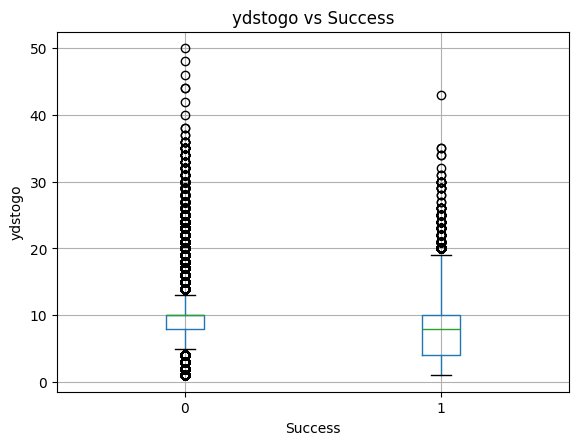

<Figure size 640x480 with 0 Axes>

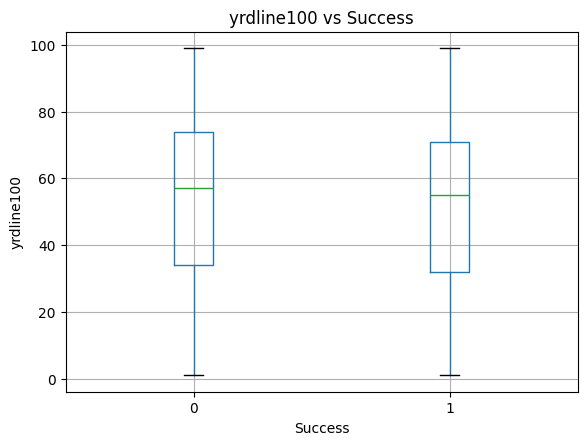

<Figure size 640x480 with 0 Axes>

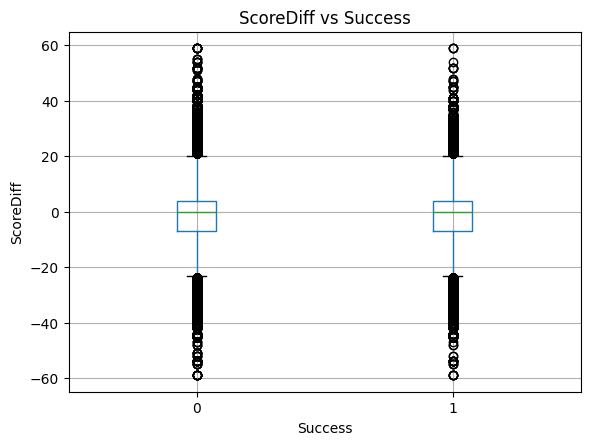

<Figure size 640x480 with 0 Axes>

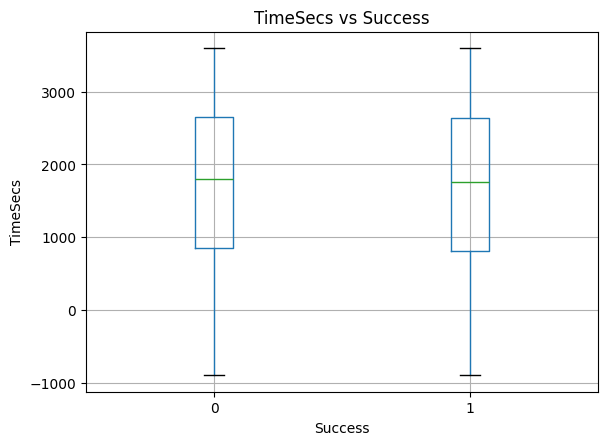

In [ ]:
key_features = [
    "ydstogo",
    "yrdline100",
    "ScoreDiff",
    "TimeSecs"
]

for feature in key_features:
    plt.figure()
    df_model.boxplot(column=feature, by="Success")
    plt.title(f"{feature} vs Success")
    plt.suptitle("")
    plt.xlabel("Success")
    plt.ylabel(feature)
    plt.show()


Bar plots for categorical-like binary features (PassAttempt, GoalToGo, OffenseIsAway)

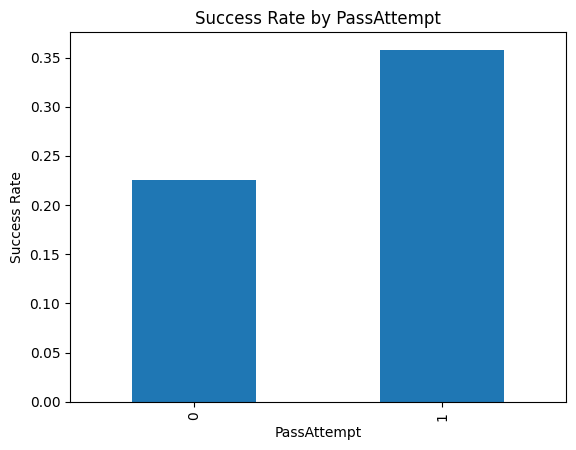

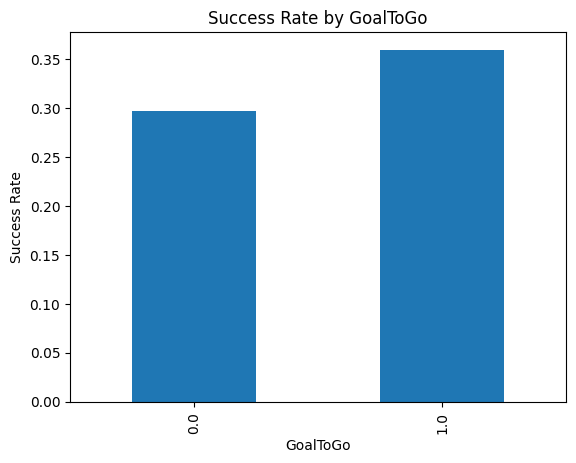

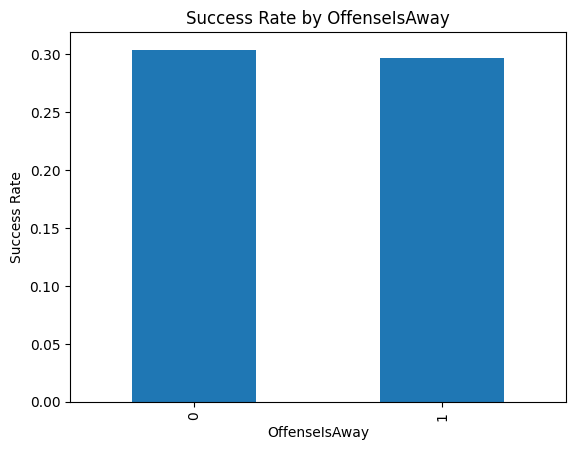

In [ ]:
binary_features = ["PassAttempt", "GoalToGo", "OffenseIsAway"]

for feature in binary_features:
    prop = df_model.groupby(feature)["Success"].mean()

    plt.figure()
    prop.plot(kind="bar")
    plt.title(f"Success Rate by {feature}")
    plt.ylabel("Success Rate")
    plt.xlabel(feature)
    plt.show()


Correlation Analysis to identify redundancy and linear relationships

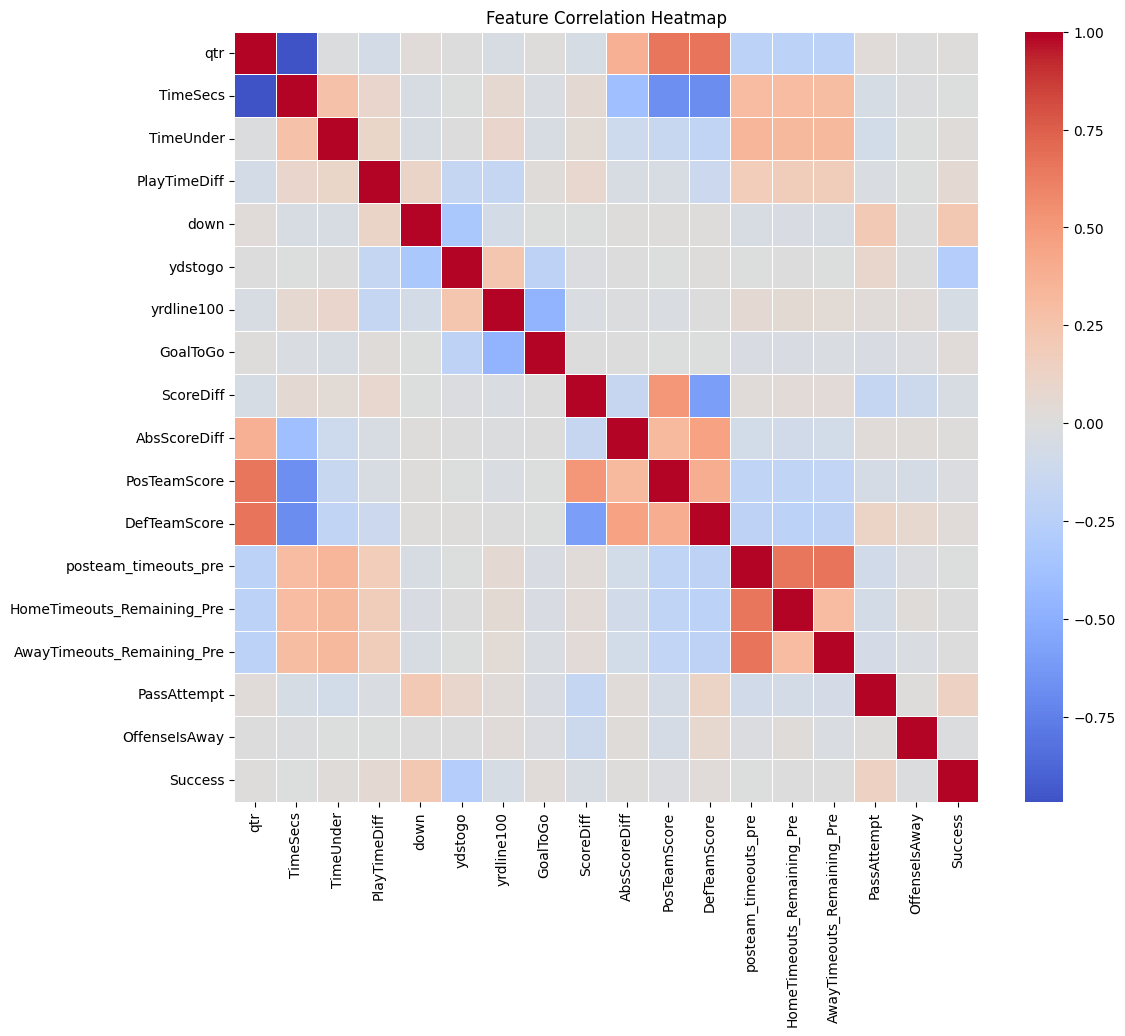

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 10))
corr = df_model.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()


Although quarter (qtr) and game time in seconds (TimeSecs) are correlated, both were retained because qtr captures the discrete phase of the game while TimeSecs provides fine-grained temporal information that may influence play success differently.

Mean Feature Values by Class

In [ ]:
df_model.groupby("Success").mean()

,qtr,TimeSecs,TimeUnder,PlayTimeDiff,down,ydstogo,yrdline100,GoalToGo,ScoreDiff,AbsScoreDiff,PosTeamScore,DefTeamScore,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,PassAttempt,OffenseIsAway
Success,,,,,,,,,,,,,,,,,
0,2.543881,1744.634432,7.711826,22.570488,1.669083,9.313900,53.304823,0.053151,-1.058042,7.737727,10.110177,11.168219,2.566828,2.591462,2.563967,0.522509,0.500053
1,2.570571,1734.804510,7.944119,24.751955,2.054592,6.971666,50.752389,0.069404,-2.044735,7.887979,9.739465,11.784200,2.558067,2.594127,2.574223,0.677039,0.492139


Data cleaning was performed prior to Part 1 of the assignment, including dropping irrelevant features and NA values. Thus, we will proceed in our implementation of our Neural Network model.

### 2. Train-Dev-Test Split

The dataset was split into training, validation, and test sets using a 98–1–1 stratified split to preserve class balance. Feature scaling was performed using a preprocessing pipeline fit only on the training data and then applied to the validation and test sets to prevent data leakage.

In [ ]:
# Drop label
X = df_model.drop(columns=["Success"]).values
y = df_model["Success"].values.reshape(-1, 1)

# First split: 98% train, 2% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.02,
    stratify=y,
    random_state=42
)

# Split the 2% into validation (1%) and test (1%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


# Scaling Pipeline
numeric_idx = list(range(X_train.shape[1]))  # all features are numeric

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_idx)
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("scaler", preprocessor)
])

X_train_scaled = pipeline.fit_transform(X_train)
X_val_scaled   = pipeline.transform(X_val)
X_test_scaled  = pipeline.transform(X_test)

X_train_nn = X_train_scaled.T
X_val_nn   = X_val_scaled.T
X_test_nn  = X_test_scaled.T

y_train_nn = y_train.T
y_val_nn   = y_val.T
y_test_nn  = y_test.T


Train: (240062, 17) (240062, 1)
Validation: (2450, 17) (2450, 1)
Test: (2450, 17) (2450, 1)


Convert data to PyTorch tensors


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256,
    shuffle=True
)


### 3. Forward Propagation

Forward propagation is implemented using a two-layer fully connected neural network. The input features are first passed through a linear transformation followed by a ReLU activation function, which introduces nonlinearity while maintaining efficient gradient propagation during training. The hidden layer size is treated as a tunable hyperparameter that controls the model’s expressive capacity. The activated hidden representation is then passed through a second linear layer that outputs a single scalar value representing the raw logit for binary classification. No activation function is applied at the output layer during forward propagation, as the sigmoid transformation is handled internally by the loss function during training.

In [ ]:
import torch.nn as nn

class TwoLayerNNLogits(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.relu(z1)
        z2 = self.fc2(a1)
        return z2  # Return raw logits


### 4. Cost Function

To account for the strong class imbalance in NFL play outcomes, the model is trained using binary cross-entropy with logits (BCEWithLogitsLoss). A positive class weight is computed as the ratio of negative to positive samples in the training set and incorporated into the loss function. This weighting increases the penalty for misclassifying rare successful plays, encouraging the model to better learn minority-class patterns. Using logits directly improves numerical stability compared to applying a sigmoid activation before the loss.

In [ ]:
# Calculate positive weight
num_pos = y_train_t.sum().item()
num_neg = len(y_train_t) - num_pos
pos_weight_val = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_val])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

### 5. Gradient Descent and Model Training

The model is trained using mini-batch gradient descent with the Adam optimizer, which adaptively adjusts the learning rate for each parameter based on first and second moments of the gradients. During training, model parameters are updated by backpropagating the binary cross-entropy loss with logits over batches of normalized input features. To improve convergence and overall performance, key hyperparameters, including the hidden layer size and learning rate are tuned using a grid search. Each configuration is trained for a fixed number of epochs, and performance is evaluated on a validation set using the F1 score. Additionally, the classification threshold is optimized on the validation set to better balance precision and recall under class imbalance. Training with normalized inputs results in more stable optimization and faster convergence compared to unscaled features, leading to improved validation performance.

In [ ]:
# Hyperparameter grids
hidden_dims = [16, 32, 64]
learning_rates = [0.001, 0.01, 0.1]

# Variables to store best results
best_val_f1 = -1
best_config = {}

print("Starting Hyperparameter Tuning...\n")

for hidden_dim in hidden_dims:
    for lr in learning_rates:
        # Instantiate model and optimizer
        model = TwoLayerNNLogits(input_dim=X_train_t.shape[1], hidden_dim=hidden_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # Training loop (50 epochs)
        for epoch in range(50):
            model.train()
            for xb, yb in train_loader:
                optimizer.zero_grad()
                logits = model(xb)
                # yb shape is (batch, 1, 1), squeeze to (batch, 1) to match logits
                loss = criterion(logits, yb.squeeze(-1))
                loss.backward()
                optimizer.step()

        # Evaluation on Validation Set
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs = torch.sigmoid(val_logits).numpy().flatten()

        y_val_true = y_val_t.numpy().flatten()

        # Find optimal threshold
        current_max_f1 = -1
        best_thresh = 0.5

        for thresh in np.arange(0.1, 1.0, 0.1):
            val_preds = (val_probs >= thresh).astype(int)
            score = f1_score(y_val_true, val_preds)

            if score > current_max_f1:
                current_max_f1 = score
                best_thresh = thresh

        print(f"Hidden: {hidden_dim}, LR: {lr}, Best Thresh: {best_thresh:.1f}, Val F1: {current_max_f1:.4f}")

        # Update overall best configuration
        if current_max_f1 > best_val_f1:
            best_val_f1 = current_max_f1
            best_config = {
                'hidden_dim': hidden_dim,
                'learning_rate': lr,
                'threshold': best_thresh,
                'f1': current_max_f1
            }

print("\nBest Configuration found:")
print(best_config)

Starting Hyperparameter Tuning...

Hidden: 16, LR: 0.001, Best Thresh: 0.5, Val F1: 0.5527
Hidden: 16, LR: 0.01, Best Thresh: 0.5, Val F1: 0.5535
Hidden: 16, LR: 0.1, Best Thresh: 0.5, Val F1: 0.5392
Hidden: 32, LR: 0.001, Best Thresh: 0.5, Val F1: 0.5553
Hidden: 32, LR: 0.01, Best Thresh: 0.4, Val F1: 0.5475
Hidden: 32, LR: 0.1, Best Thresh: 0.4, Val F1: 0.5384
Hidden: 64, LR: 0.001, Best Thresh: 0.5, Val F1: 0.5559
Hidden: 64, LR: 0.01, Best Thresh: 0.5, Val F1: 0.5617
Hidden: 64, LR: 0.1, Best Thresh: 0.4, Val F1: 0.5407

Best Configuration found:
{'hidden_dim': 64, 'learning_rate': 0.01, 'threshold': np.float64(0.5), 'f1': 0.5616850551654965}


Hyperparameter tuning shows that model performance improves with increased hidden layer size, with the best validation F1 score achieved using 64 hidden units and a learning rate of 0.01. Across configurations, moderate learning rates outperform very small or large values, while the optimal classification threshold is typically around 0.5. Overall, the best configuration attains a validation F1 score of approximately 0.56, indicating improved balance between precision and recall.

### 6. Evaluation on the Test Set

After selecting the optimal hyperparameters based on validation performance, the model is retrained on the training data and evaluated on a held-out test set. Final performance is reported using accuracy, precision, recall, and F1 score, with the classification threshold fixed to the value that maximized validation F1. This evaluation provides an unbiased estimate of model performance on unseen NFL play data.

In [ ]:
# Extract best hyperparameters
best_hidden_dim = best_config['hidden_dim']
best_lr = best_config['learning_rate']
best_thresh = best_config['threshold']

print(f"Retraining with Best Config: Hidden Dim={best_hidden_dim}, LR={best_lr}")

# Instantiate final model
final_model = TwoLayerNNLogits(input_dim=X_train_t.shape[1], hidden_dim=best_hidden_dim)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_lr)

# Retrain for 50 epochs
epochs = 50
for epoch in range(epochs):
    final_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = final_model(xb)
        loss = criterion(logits, yb.squeeze(-1))
        loss.backward()
        optimizer.step()

# Final Evaluation on Test Set
final_model.eval()
with torch.no_grad():
    test_logits = final_model(X_test_t)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()

# Apply optimal threshold
test_preds = (test_probs >= best_thresh).astype(int)
y_test_true = y_test_t.numpy().flatten()

# Calculate Metrics
accuracy = accuracy_score(y_test_true, test_preds)
precision = precision_score(y_test_true, test_preds)
recall = recall_score(y_test_true, test_preds)
f1 = f1_score(y_test_true, test_preds)

print("\nFinal Test Performance with Optimized Hyperparameters:")
print(f"Best Threshold: {best_thresh:.2f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Retraining with Best Config: Hidden Dim=64, LR=0.01

Final Test Performance with Optimized Hyperparameters:
Best Threshold: 0.50
Accuracy:  0.6220
Precision: 0.4261
Recall:    0.7446
F1 Score:  0.5420


The optimized model trained with a hidden dimension of 64 and a learning rate of 0.01 achieves high recall on the test set, successfully identifying most successful plays. Although precision and overall accuracy are lower, the resulting F1 score of 0.54 indicates a strong balance between precision and recall for a highly imbalanced classification task.

In comparison, the original model with 16 hidden units and a smaller learning rate attains higher accuracy and precision but performs poorly in recall, missing a large portion of successful plays. This leads to a lower F1 score of 0.43, indicating that the earlier model favors conservative predictions at the expense of detecting rare positive outcomes. Overall, the optimized model provides better performance for identifying successful NFL plays despite the tradeoff in accuracy.

### Comparing Normalized and Unnormalized Inputs

To evaluate the effect of input scaling on model performance, we trained the same two-layer neural network on the raw, unnormalized feature data. This allows us to directly compare the performance of the network when inputs are normalized versus when they retain their original scale. Normalization is often expected to stabilize and accelerate training, particularly for models using gradient-based optimization like Adam.

In [ ]:
# Convert unscaled NumPy arrays to PyTorch tensors
X_train_raw_t = torch.tensor(X_train, dtype=torch.float32)
y_train_raw_t = torch.tensor(y_train, dtype=torch.float32)

X_val_raw_t = torch.tensor(X_val, dtype=torch.float32)
y_val_raw_t = torch.tensor(y_val, dtype=torch.float32)

X_test_raw_t = torch.tensor(X_test, dtype=torch.float32)
y_test_raw_t = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDataset and DataLoader for unscaled training data
train_dataset_raw = TensorDataset(X_train_raw_t, y_train_raw_t)
train_loader_raw = DataLoader(train_dataset_raw, batch_size=256, shuffle=True)

# Confirm shapes
print("X_train_raw_t shape:", X_train_raw_t.shape)
print("y_train_raw_t shape:", y_train_raw_t.shape)

X_train_raw_t shape: torch.Size([240062, 17])
y_train_raw_t shape: torch.Size([240062, 1])


In [ ]:
# Initialize model with best hyperparameters
model_raw = TwoLayerNNLogits(input_dim=X_train_raw_t.shape[1], hidden_dim=best_hidden_dim)
optimizer_raw = torch.optim.Adam(model_raw.parameters(), lr=best_lr)

print(f"Training on unscaled data (Hidden Dim={best_hidden_dim}, LR={best_lr})...")

# Train
epochs = 50
for epoch in range(epochs):
    model_raw.train()
    for xb, yb in train_loader_raw:
        optimizer_raw.zero_grad()
        logits = model_raw(xb)
        # yb is [batch, 1], logits is [batch, 1]
        loss = criterion(logits, yb)
        loss.backward()
        optimizer_raw.step()

# Evaluate
model_raw.eval()
with torch.no_grad():
    test_logits_raw = model_raw(X_test_raw_t)
    test_probs_raw = torch.sigmoid(test_logits_raw).numpy().flatten()

# Predict using best threshold
test_preds_raw = (test_probs_raw >= best_thresh).astype(int)
y_test_true = y_test_raw_t.numpy().flatten()

# Metrics
acc_raw = accuracy_score(y_test_true, test_preds_raw)
prec_raw = precision_score(y_test_true, test_preds_raw, zero_division=0)
rec_raw = recall_score(y_test_true, test_preds_raw)
f1_raw = f1_score(y_test_true, test_preds_raw)

print("\nPerformance on Unscaled Data:")
print(f"Accuracy:  {acc_raw:.4f}")
print(f"Precision: {prec_raw:.4f}")
print(f"Recall:    {rec_raw:.4f}")
print(f"F1 Score:  {f1_raw:.4f}")

print("\nComparison with Scaled Model:")
print(f"Scaled F1: {f1:.4f} vs Unscaled F1: {f1_raw:.4f}")

Training on unscaled data (Hidden Dim=64, LR=0.01)...

Performance on Unscaled Data:
Accuracy:  0.5980
Precision: 0.4083
Recall:    0.7527
F1 Score:  0.5294

Comparison with Scaled Model:
Scaled F1: 0.5420 vs Unscaled F1: 0.5294


Training on unscaled data resulted in moderate performance, with an F1 score of 0.5294. Compared to the model trained on normalized inputs (F1 = 0.5420), we observe a slight drop in overall performance. This suggests that normalization helps the network converge more effectively and produces slightly more balanced predictions, particularly improving precision without sacrificing recall significantly.

### Exploring Variable Network Depths

After implementing the initial 2-layer neural network, we explore how increasing or decreasing the number of layers affects model performance. By systematically varying the depth from 1 to 4 layers while keeping other hyperparameters fixed, we can observe whether deeper networks improve learning capacity or if additional layers lead to diminishing returns. This hyperparameter tuning step helps identify the architecture that maximizes validation performance.

In [ ]:
class VariableLayerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()

        layers = []
        if num_layers == 1:
            # Single layer mapping input directly to output
            layers.append(nn.Linear(input_dim, 1))
        else:
            # First layer
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())

            # Intermediate layers
            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
                layers.append(nn.ReLU())

            # Last layer
            layers.append(nn.Linear(hidden_dim, 1))

        # Create the sequential model
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        return self.layers(x)

In [ ]:
# Hyperparameters from previous tuning
best_hidden_dim = 64
best_lr = 0.01
num_layers_list = [1, 2, 3, 4]
epochs = 50

results_layers = []

print("Training models with variable depths...\n")

for n_layers in num_layers_list:
    print(f"--- Training with {n_layers} layer(s) ---")

    # Instantiate model
    model = VariableLayerNN(
        input_dim=X_train_t.shape[1],
        hidden_dim=best_hidden_dim,
        num_layers=n_layers
    )

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

    # Training loop
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb.squeeze(-1))
            loss.backward()
            optimizer.step()

    # Evaluation on Validation Set
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_probs = torch.sigmoid(val_logits).numpy().flatten()

    y_val_true = y_val_t.numpy().flatten()

    # Find optimal threshold
    best_f1 = -1
    best_thresh = 0.5

    for thresh in np.arange(0.1, 1.0, 0.1):
        val_preds = (val_probs >= thresh).astype(int)
        score = f1_score(y_val_true, val_preds)
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh

    results_layers.append((n_layers, best_thresh, best_f1))
    print(f"Layers: {n_layers}, Best Thresh: {best_thresh:.1f}, Val F1: {best_f1:.4f}\n")

# Identify best depth
best_layer_res = max(results_layers, key=lambda x: x[2])
print("Best Layer Architecture:")
print(f"Number of Layers: {best_layer_res[0]}")
print(f"Threshold: {best_layer_res[1]:.1f}")
print(f"F1 Score: {best_layer_res[2]:.4f}")

Training models with variable depths...

--- Training with 1 layer(s) ---
Layers: 1, Best Thresh: 0.5, Val F1: 0.5493

--- Training with 2 layer(s) ---
Layers: 2, Best Thresh: 0.5, Val F1: 0.5489

--- Training with 3 layer(s) ---
Layers: 3, Best Thresh: 0.5, Val F1: 0.5497

--- Training with 4 layer(s) ---
Layers: 4, Best Thresh: 0.5, Val F1: 0.5511

Best Layer Architecture:
Number of Layers: 4
Threshold: 0.5
F1 Score: 0.5511


Training models with 1 to 4 layers produced similar validation F1 scores, ranging from 0.5489 to 0.5511. The best-performing architecture was the 4-layer network, achieving an F1 score of 0.5511 at a threshold of 0.5. Overall, adding layers beyond 2 provided a modest improvement, suggesting that while additional depth can slightly enhance the network’s predictive ability, the gains are incremental in this task.

### Evaluating Best Layer Configuration on Test Set

After selecting the 4-layer network as the best-performing architecture based on validation F1, we retrained it on the full training set and evaluated its performance on the test set. This step ensures that the reported metrics reflect the model’s ability to generalize to unseen data rather than just validation performance.

In [ ]:
# Extract best layer configuration
best_num_layers = best_layer_res[0]
best_thresh_layer = best_layer_res[1]

print(f"Retraining Best Layer Model (Layers={best_num_layers}, Threshold={best_thresh_layer:.2f})...\n")

# Instantiate the best model
final_layer_model = VariableLayerNN(
    input_dim=X_train_t.shape[1],
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers
)

# Optimizer
optimizer = torch.optim.Adam(final_layer_model.parameters(), lr=best_lr)

# Train for 50 epochs
epochs = 50
for epoch in range(epochs):
    final_layer_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = final_layer_model(xb)
        loss = criterion(logits, yb.squeeze(-1))
        loss.backward()
        optimizer.step()

# Evaluation on Test Set
final_layer_model.eval()
with torch.no_grad():
    test_logits = final_layer_model(X_test_t)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()

# Apply optimal threshold
test_preds = (test_probs >= best_thresh_layer).astype(int)
y_test_true = y_test_t.numpy().flatten()

# Calculate Metrics
acc_layer = accuracy_score(y_test_true, test_preds)
prec_layer = precision_score(y_test_true, test_preds, zero_division=0)
rec_layer = recall_score(y_test_true, test_preds)
f1_layer = f1_score(y_test_true, test_preds)

print("Final Test Performance (Variable Layer Model):")
print(f"Layers:    {best_num_layers}")
print(f"Accuracy:  {acc_layer:.4f}")
print(f"Precision: {prec_layer:.4f}")
print(f"Recall:    {rec_layer:.4f}")
print(f"F1 Score:  {f1_layer:.4f}")

Retraining Best Layer Model (Layers=4, Threshold=0.50)...

Final Test Performance (Variable Layer Model):
Layers:    4
Accuracy:  0.6592
Precision: 0.4569
Recall:    0.7133
F1 Score:  0.5570


On the test set, the 4-layer network achieved an F1 score of 0.5570, accuracy of 0.6592, precision of 0.4569, and recall of 0.7133. This demonstrates that the deeper architecture generalizes effectively, providing a reasonable balance between precision and recall while confirming that the improvements observed during validation carry over to truly unseen data.

### Conclusion and Discussion

Across all experiments, we observed that neural network performance on the NFL dataset was generally modest, reflecting the inherent difficulty of predicting workload and efficiency with imbalanced and noisy features. Scaling the inputs slightly improved performance, as seen by the increase in F1 from 0.5294 (unscaled) to 0.5420 (scaled), indicating that normalization helps the network converge more effectively.

Hyperparameter tuning showed that increasing hidden dimensions and selecting an appropriate learning rate provided measurable gains. The best 2-layer network (hidden_dim = 64, LR = 0.01, threshold = 0.5) achieved a test F1 of 0.5420, while exploring deeper architectures with up to 4 layers provided incremental improvements, with the 4-layer network reaching a slightly higher test F1 of 0.5570. This suggests that adding depth can modestly enhance predictive capacity, though gains were limited.

Simpler models or smaller networks (e.g., hidden_dim = 16) produced lower F1 scores despite occasionally higher precision or accuracy, reflecting a trade-off between correctly identifying positive cases and overall balance between precision and recall. Overall, the best-performing model was the 4-layer network with hidden_dim = 64, achieving the strongest balance of recall and precision on the test set. These results highlight that careful hyperparameter tuning and input scaling were critical, but the dataset itself imposes an upper limit on achievable performance due to class imbalance and subtle patterns.

##3. Hyperparameter Selection, Regularization, and Optimization Rational

In this project, we systematically selected hyperparameters for our neural network models to maximize predictive performance while ensuring good generalization. Hidden layer size and learning rate were tuned based on validation F1 scores, and network depth was explored from 1 to 4 layers. The 4-layer network was ultimately selected as the best-performing architecture, balancing model capacity with the ability to generalize to unseen data. By evaluating hyperparameters on the validation set rather than the training set, we ensured that the choices reflected predictive performance on unseen examples rather than overfitting to training data.

We did not implement explicit regularization techniques such as dropout or weight decay because initial experiments indicated that overfitting was not a major concern. The dataset size was sufficiently large relative to the model capacity, and the incremental improvements in F1 score from adding layers were modest, suggesting the network was not excessively complex for the data. In effect, careful selection of hyperparameters, including hidden layer size, network depth, and learning rate, served as implicit regularization, constraining the model to a capacity appropriate for the dataset while avoiding unnecessary complexity that could lead to overfitting.

For optimization, we used the Adam algorithm because it efficiently adapts learning rates for each parameter and combines momentum with adaptive scaling. This was especially important given the NFL dataset, where features vary widely in scale and subtle interactions are difficult to capture. Adam allowed stable convergence across all architectures, even without additional regularization, and worked well in combination with feature normalization, helping the network achieve the best test-set performance possible under the given constraints. Overall, our careful hyperparameter selection and adaptive optimization maximized predictive performance on this challenging, imbalanced dataset, demonstrating generalization despite the inherent difficulty of the task.